## Land Cover
- also see notes in dendron about LC
- 

In [39]:
%matplotlib inline
%matplotlib widget

import sys, os

import datacube
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

sys.path.insert(1, '../Tools/')

from dea_tools.plotting import rgb, display_map
from dea_tools.landcover import plot_land_cover, lc_colourmap, make_colorbar
from matplotlib import colors as mcolors

In [40]:
dc = datacube.Datacube(app='jenna_landcover_playgrouns')

In [41]:
product = 'ga_ls_landcover_class_cyear_2'

measurements = dc.list_measurements()
measurements.loc[product]

measurements=[
        'level3',
        'lifeform',
        'vegetation_cover',
        'water_seasonality',
        'water_state',
        'intertidal',
        'water_persistence',
        'bare_gradation',
        'full_classification'
    ]

In [42]:
# set up study area

lat = -18.10
lon = 122.32
buffer = 0.18

lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

time_range=('2017', '2020')

In [43]:
#display_map(x=lon_range, y=lat_range)

In [44]:
query = {
    'y': lat_range,
    'x': lon_range,
    'time': time_range
}

In [45]:
lc = dc.load(
    product=product,
    measurements=measurements,
    resolution=(-25,25),
    **query
)

In [46]:
#lc

### viz

There are two ways to visualise the LC data: `plot_layer()` lets you make your own color scheme, `plot_land_cover()` is a DEA function that uses DEA's standard colour maps.

In [47]:
LEVEL3_COLOUR_SCHEME = {
    0: (255, 255, 255, 255, "No Data"),
    111: (172, 188, 45, 255, "Cultivated terrestrial vegetation"),
    112: (14, 121, 18, 255, "Natural terrestrial vegetation"),
    124: (30, 191, 121, 255, "Natural aquatic vegetation"),
    215: (218, 92, 105, 255, "Artificial surface"),
    216: (243, 171, 105, 255, "Natural bare surface"),
    220: (77, 159, 220, 255, "Water")
}

In [48]:
# PLOT LAYER FROM COLOUR MAP

def plot_layer(colours, data):
    colour_arr = []

    for key, value in colours.items():
        colour_arr.append(np.array(value[:-2])/255)

    cmap = mcolors.ListedColormap(colour_arr)
    bounds = list(colours)
    bounds.append(255)
    norm = mcolors.BoundaryNorm(np.array(bounds) - 0.1, cmap.N)

    labels = {'ticks': [0, 111, 112, 124, 215, 216, 220]}

    if len(data.time) == 1:
        im = data.isel(time=0).plot(
            cmap = cmap, norm=norm, add_colorbar=True, size=5, cbar_kwargs=labels
        )
    else:
        im = data.plot(cmap=cmap, norm=norm, add_colorbar=True, col='time', col_wrap=4, size=5, cbar_kwargs=labels)

    return im

In [49]:
#plot_layer(LEVEL3_COLOUR_SCHEME, lc.level3)

In [50]:
#plot_land_cover(lc.water_seasonality[:, 100:300, 400:600]) #zoomed in to see

In [51]:
#plot_land_cover(lc.full_classification, year='2020')

## Land Cover pixel drilling


In [52]:
# custom functions

def rescale_level3(data):
    """
    rescale dist of L3 classes to 0-6 for neat plotting.
    input: xr dataset or dataarray with L3 land cover data
    """
    scale_and_labels = {
        0:0,
        111:1,
        112:2,
        124:3,
        215:4,
        216:5,
        220:6
    }

    for key,value in scale_and_labels.items():
        data = data.where(data != key, value)
    return data


def click_for_coords(event):
    """
    define widget behaviour to extract x,y vals for a point selected with mouse click on interactive plot.
    For use with matplotlib imshow
    returns pixel x,y values for coordinate positions, not the lat/lon of the point
    you need this coord position later to d the actual pixel drill
    returns: ix, iy = position of selected pixel in the x,y coords of the array
    """
    global ix, iy
    ix, iy = event.xdata, event.ydata
    global coords
    coords.append((ix, iy))

    fig.canvas.mpl_disconnect(cid)
    return

# look up how this function is working

In [53]:
# define AOI and load data

point_x, point_y = (-35.1064, 149.4248)

buffer = 0.1

lat = (point_x - buffer, point_x + buffer)
lon = (point_y - buffer, point_y + buffer)

display_map(x=lon, y=lat)

In [54]:
query = {
    'y': lat,
    'x': lon,
    'time': ('1988','2020')
}

In [55]:
all_data = dc.load(
    product=product,
    measurements = ['level3'],
    output_crs='EPSG:3577',
    resolution=(-25,25),
    **query
)

all_data

<xarray.Dataset> Size: 27MB
Dimensions:      (time: 33, y: 982, x: 842)
Coordinates:
  * time         (time) datetime64[ns] 264B 1988-01-01 1989-01-01 ... 2020-01-01
  * y            (y) float64 8kB -3.93e+06 -3.93e+06 ... -3.954e+06 -3.954e+06
  * x            (x) float64 7kB 1.569e+06 1.569e+06 ... 1.59e+06 1.59e+06
    spatial_ref  int32 4B 3577
Data variables:
    level3       (time, y, x) uint8 27MB 112 112 112 112 111 ... 112 112 112 112
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [56]:
level3 = all_data.level3
level3

<xarray.DataArray 'level3' (time: 33, y: 982, x: 842)> Size: 27MB
array([[[112, 112, 112, ..., 112, 111, 111],
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 111, 111, 111],
        ...,
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112]],

       [[112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 111, 112, 111],
        [112, 112, 112, ..., 111, 111, 111],
        ...,
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112]],

       [[112, 112, 112, ..., 111, 112, 111],
        [112, 112, 112, ..., 111, 112, 111],
        [112, 112, 112, ..., 111, 111, 111],
        ...,
...
        ...,
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112]],

       [[112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112],
        ...,
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112]],

       [[112, 112, 112, ..., 111, 112, 111],
        [112, 112, 112, ..., 111, 111, 111],
        [112, 112, 112, ..., 111, 111, 111],
        ...,
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112],
        [112, 112, 112, ..., 112, 112, 112]]], dtype=uint8)
Coordinates:
  * time         (time) datetime64[ns] 264B 1988-01-01 1989-01-01 ... 2020-01-01
  * y            (y) float64 8kB -3.93e+06 -3.93e+06 ... -3.954e+06 -3.954e+06
  * x            (x) float64 7kB 1.569e+06 1.569e+06 ... 1.59e+06 1.59e+06
    spatial_ref  int32 4B 3577
Attributes:
    units:         1
    nodata:        0
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## visualizing:
the plot will be used to select the pixel we want to analyse further down the notebook. Select the point to interrogate by clicking with mouse, then run the code cell below.

In [57]:
"""
For some reason I need to extract the plot year array before imshow(),
even though the code works in the original notebook and I can't see the difference?
"""
plot_year = '2020'
test = level3.sel(time=plot_year, method='nearest').squeeze()

test

<xarray.DataArray 'level3' (y: 982, x: 842)> Size: 827kB
array([[112, 112, 112, ..., 111, 112, 111],
       [112, 112, 112, ..., 111, 111, 111],
       [112, 112, 112, ..., 111, 111, 111],
       ...,
       [112, 112, 112, ..., 112, 112, 112],
       [112, 112, 112, ..., 112, 112, 112],
       [112, 112, 112, ..., 112, 112, 112]], dtype=uint8)
Coordinates:
    time         datetime64[ns] 8B 2020-01-01
  * y            (y) float64 8kB -3.93e+06 -3.93e+06 ... -3.954e+06 -3.954e+06
  * x            (x) float64 7kB 1.569e+06 1.569e+06 ... 1.59e+06 1.59e+06
    spatial_ref  int32 4B 3577
Attributes:
    units:         1
    nodata:        0
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

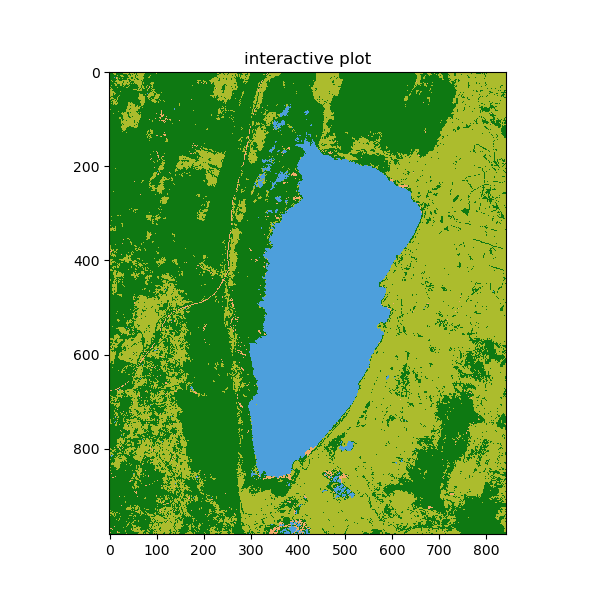

In [58]:
# build colour map for level 3
layer_cmap, layer_norm = lc_colourmap('level3')

# select years to plot
plot_year = '2020'

#create interactive plot
fig, ax = plt.subplots(figsize=(6,6))
ax = plt.imshow(
    test,
    cmap=layer_cmap,
    norm=layer_norm,
    interpolation='nearest'
)

cid=fig.canvas.mpl_connect('button_press_event', click_for_coords)
plt.title('interactive plot')

plt.show()

In [59]:
# enter selected point
plt.clf()
ax = plt.imshow(
    test,
    cmap=layer_cmap,
    norm=layer_norm,
    interpolation='nearest'
)

plt.scatter(x=ix, y=iy, c='r', s=80)

NameError: name 'ix' is not defined

In [ ]:
# Do the actual pixel drilling
pixel_timeseries = level3.isel(
    x=int(ix),
    y=int(iy)
)

new_data = rescale_level3(pixel_timeseries)

In [ ]:
# plot the land cover history of the point

fig, ax = plt.subplots(figsize=(8,4))

number_labels = (0,1,2,3,4,5,6)
label_classes = (
    'no data',
    'CTV',
    'NTV',
    'NAV',
    'AS',
    'NS',
    'water'
)

plt.yticks(number_labels, label_classes)

new_data.plot(linestyle='--', c='b', marker='8', mec='b', mfc='b')
plt.xlabel('year')
plt.ylabel('level3 land cover class')
plt.title('land cov history for selected pixel')
plt.grid()
plt.tight_layout()
plt.show()

## Change detection mapping

In [ ]:
lat, lon = (-37.9, 144.7)

buffer = 0.02

lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

time_range=('2010', '2020')

In [ ]:
display_map(x=lon_range, y=lat_range)

In [ ]:
query = {
    'y': lat_range,
    'x': lon_range,
    'time': time_range
}

In [ ]:
lc = dc.load(
    product=product,
    measurements=['level3'],
    output_crs='EPSG:3577',
    resolution=(-25, 25),
    **query
)

In [ ]:
plot_land_cover(lc.level3)

In [ ]:
start = lc.level3[0].astype(np.int32)
end = lc.level3[-1].astype(np.int32)

ignore_no_change=True

In [ ]:
# combine classifications from start and end dates
change_vals = (start * 1000) + end

# mask vals with no changes by setting to 0 if this is requested
if ignore_no_change:
    change_vals = np.where(start == end, 0, change_vals)

In [ ]:
level_3 = lc.level3[0].drop_vars('time')

In [ ]:
# create new dataarray

change = xr.DataArray(
    data = change_vals,
    coords = level_3.coords,
    dims = level_3.dims,
    name='change',
    attrs=level_3.attrs
)

In [ ]:
cmap, norm = lc_colourmap('level3_change_colour_scheme')
# make fig
fig, ax = plt.subplots(figsize=(9,7))

make_colorbar(fig, ax, measurement='level3_change_colour_scheme')

img = ax.imshow(change, cmap=cmap, norm=norm, interpolation='nearest')

### Plot 2 change maps using NTV and AS data
This lets us see loss/gain of NTV and AS loss/gain (urban expansion)

In [ ]:
# the change nums are the codes for the classes - so 111112 is 111 (CTV) and 112(NTV)
NTV_increase = np.where(
    (
        (change == 111112)
        |(change == 124112)
        |(change == 215112)
        |(change == 216112)
        |(change == 220112)
    ),
    -1,
    0
)

In [ ]:
NTV_decrease = np.where(
    (
        (change == 112111)
        |(change == 112124)
        |(change == 112215)
        |(change == 112216)
        |(change == 112220)
    ),
    -1,
    0
)

In [ ]:
AS_increase = np.where(
    (
        (change == 111215)
        |(change == 112215)
        |(change == 124215)
        |(change == 216215)
        |(change == 220215)
    ),
    -1,
    0
)

In [ ]:
AS_decrease = np.where(
    (
        (change == 215111)
        |(change == 215122)
        |(change == 215124)
        |(change == 215216)
        |(change == 215220)
    ),
    -1,
    0
)

In [ ]:
NTV_change = NTV_increase + NTV_decrease

In [ ]:
AS_change = AS_increase + AS_decrease

In [ ]:
# new xarray for the change data
xr_ntvchange = xr.DataArray(
    data=NTV_change,
    coords=change.coords,
    dims=change.dims,
    name='ntv_change',
    attrs=None
)

xr_aschange = xr.DataArray(
    data=AS_change,
    coords=change.coords,
    dims=change.dims,
    name='as_change',
    attrs=None
)

In [ ]:
xr_ntvchange

In [ ]:
# plot them to see
as_cmap=mcolors.ListedColormap(['b', 'white', 'lightpink'])

In [ ]:
xr_ntvchange.plot.imshow(cmap='bwr_r')

In [ ]:

xr_aschange.plot.imshow(cmap=as_cmap)